In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats
%pip install -q statsmodels
import statsmodels.api as sm
import sklearn as skl

Note: you may need to restart the kernel to use updated packages.


In [194]:
#read all files into pandas dataframes
campaign_data = pd.read_csv('campaign_desc.csv')
campaign_table = pd.read_csv('campaign_table.csv')
causal_data = pd.read_csv('causal_data.csv')
coupon_redemption = pd.read_csv('coupon_redempt.csv')
coupon_table = pd.read_csv('coupon.csv')
hh_demographic = pd.read_csv('hh_demographic.csv')
product = pd.read_csv('product.csv')
transaction_data = pd.read_csv('transaction_data.csv')

In [195]:
#explore campaign data
campaign_data.info()
campaign_data.head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   DESCRIPTION  30 non-null     object
 1   CAMPAIGN     30 non-null     int64 
 2   START_DAY    30 non-null     int64 
 3   END_DAY      30 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.1+ KB


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


In [196]:
#explore campaign_table data
campaign_table.info()
campaign_table.head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DESCRIPTION    7208 non-null   object
 1   household_key  7208 non-null   int64 
 2   CAMPAIGN       7208 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 169.1+ KB


,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [197]:
#explore causal data
causal_data.info()
causal_data.sort_values(by='WEEK_NO', ascending=True).head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36786524 entries, 0 to 36786523
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   PRODUCT_ID  int64 
 1   STORE_ID    int64 
 2   WEEK_NO     int64 
 3   display     object
 4   mailer      object
dtypes: int64(3), object(2)
memory usage: 1.4+ GB


,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
9625488,940895,31762,9,0,A
24256051,2254157,440,9,4,A
19809507,1474756,309,9,0,A
30824904,8280083,359,9,6,0
30824874,8280083,356,9,5,0


In [198]:
# explore coupon redemption data
coupon_redemption.info()
coupon_redemption.sort_values(by='DAY', ascending=True).head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   household_key  2318 non-null   int64
 1   DAY            2318 non-null   int64
 2   COUPON_UPC     2318 non-null   int64
 3   CAMPAIGN       2318 non-null   int64
dtypes: int64(4)
memory usage: 72.6 KB


,household_key,DAY,COUPON_UPC,CAMPAIGN
2007,2280,225,57008510075,26
1987,2240,226,53600000001,26
717,788,227,55100055008,26
718,788,227,57218020076,26
716,788,227,51111076635,26


In [199]:
#explore coupon table data
coupon_table.info()
coupon_table.head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124548 entries, 0 to 124547
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   COUPON_UPC  124548 non-null  int64
 1   PRODUCT_ID  124548 non-null  int64
 2   CAMPAIGN    124548 non-null  int64
dtypes: int64(3)
memory usage: 2.9 MB


,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [200]:
#explore hh_demographic data
hh_demographic.info()
hh_demographic.head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   AGE_DESC             801 non-null    object
 1   MARITAL_STATUS_CODE  801 non-null    object
 2   INCOME_DESC          801 non-null    object
 3   HOMEOWNER_DESC       801 non-null    object
 4   HH_COMP_DESC         801 non-null    object
 5   HOUSEHOLD_SIZE_DESC  801 non-null    object
 6   KID_CATEGORY_DESC    801 non-null    object
 7   household_key        801 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 50.2+ KB


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [201]:
#explore product data
product.info()
product.head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   PRODUCT_ID            92353 non-null  int64 
 1   MANUFACTURER          92353 non-null  int64 
 2   DEPARTMENT            92353 non-null  object
 3   BRAND                 92353 non-null  object
 4   COMMODITY_DESC        92353 non-null  object
 5   SUB_COMMODITY_DESC    92353 non-null  object
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.9+ MB


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [202]:
#explore transaction data
transaction_data.info()
transaction_data.head(n=5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


**Setup.** Import thư viện và định nghĩa vài hàm/biến dùng chung. Chạy 1 lần đầu tiên, ngay sau cell đọc dữ liệu của teammate. Đây là bản tinh giản tối đa - chỉ giữ cell trực tiếp phục vụ BQ1 và Q1, không có cell nào chỉ mang tính minh họa/phụ.

In [203]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
COLORS = sns.color_palette("Set2")  # bảng màu dùng chung cho mọi chart
OUT_DIR = "outputs"  # CSV exports only now - charts stay inline, no PNG files
os.makedirs(OUT_DIR, exist_ok=True)

def show_chart(fig):  # canh layout rồi hiện chart ngay trong notebook, không lưu file
    fig.tight_layout()
    plt.show()
    plt.close(fig)

# age và income là ordinal (có thứ tự), nên sort tay thay vì alphabet
age_order = ["19-24", "25-34", "35-44", "45-54", "55-64", "65+"]

def income_floor(label):  # lấy mốc dưới của mỗi khoảng thu nhập để sort
    if label.lower().startswith("under"):
        return -1
    digits = "".join(c for c in label.split("-")[0] if c.isdigit())
    return int(digits) if digits else 999

**Bước 1 - Nhìn tổng quan campaign.** Timeline 30 campaign: chạy khi nào, dài bao lâu, thuộc loại gì. Cũng là cơ sở cho bảng tổng hợp Q1 ở cuối.

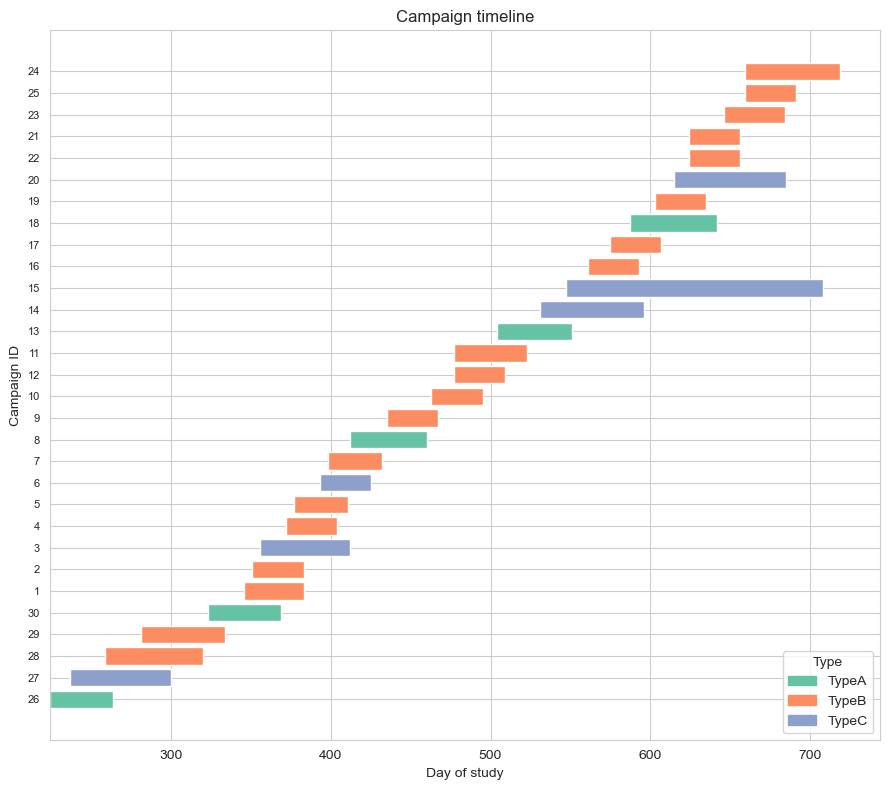

In [204]:
df_campaign = campaign_data.copy()
df_campaign["DURATION"] = df_campaign["END_DAY"] - df_campaign["START_DAY"]  # số ngày campaign chạy
campaign_types = sorted(df_campaign["DESCRIPTION"].unique())  # danh sách loại campaign

df_sorted = df_campaign.sort_values("START_DAY").reset_index(drop=True)  # sắp theo ngày bắt đầu
colors = [COLORS[campaign_types.index(t)] for t in df_sorted["DESCRIPTION"]]  # mỗi loại 1 màu riêng

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(range(len(df_sorted)), df_sorted["DURATION"], left=df_sorted["START_DAY"], color=colors)  # mỗi thanh = 1 campaign, độ dài = duration
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted["CAMPAIGN"], fontsize=8)
ax.set_title("Campaign timeline")
ax.set_xlabel("Day of study")
ax.set_ylabel("Campaign ID")
handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[i]) for i in range(len(campaign_types))]
ax.legend(handles, campaign_types, title="Type", loc="lower right")
show_chart(fig)

**Households bị target.** Mỗi campaign target số lượng household rất khác nhau - đây là lý do Q1 dùng số household được target (reach) làm tiêu chí phân loại Small/Medium/Large.

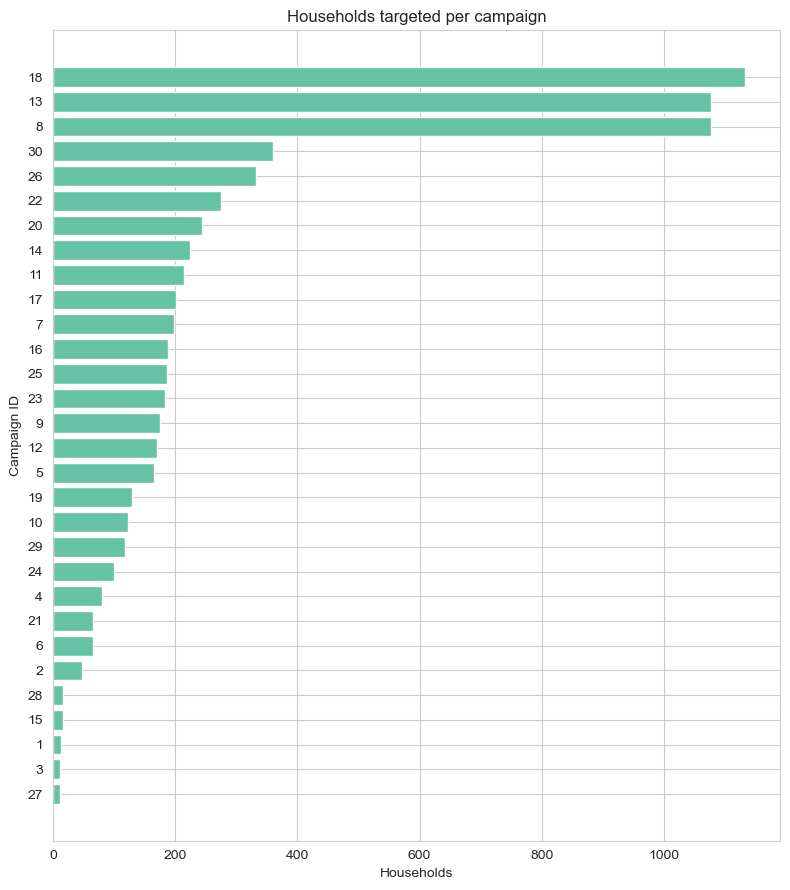

In [205]:
per_campaign = campaign_table.groupby("CAMPAIGN").size().sort_values(ascending=False)  # đếm số dòng = số household mỗi campaign

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(per_campaign.index.astype(str), per_campaign.values, color=COLORS[0])
ax.invert_yaxis()
ax.set_title("Households targeted per campaign")
ax.set_xlabel("Households")
ax.set_ylabel("Campaign ID")
show_chart(fig)

**Ai là khách hàng (tuổi) - baseline.** Phân bố tuổi của toàn bộ household có dữ liệu demographic, để so sánh với age mix của từng loại campaign ở BQ1 Bước 2 (households bị target có lệch khỏi baseline này không).

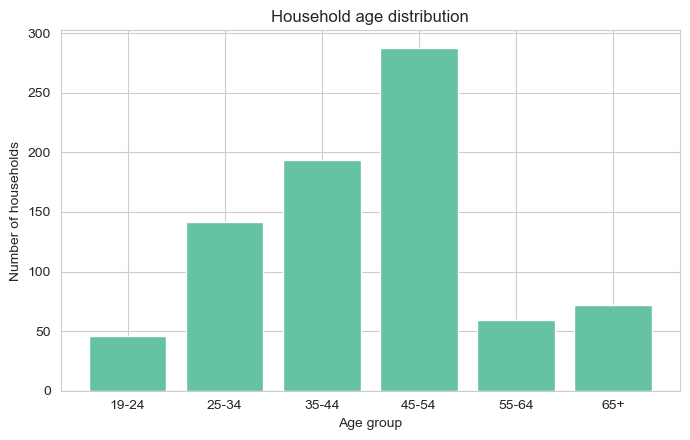

In [206]:
age_counts = hh_demographic["AGE_DESC"].value_counts().reindex(age_order)  # đếm household theo từng nhóm tuổi

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(age_counts.index, age_counts.values, color=COLORS[0])
ax.set_title("Household age distribution")
ax.set_xlabel("Age group")
ax.set_ylabel("Number of households")
show_chart(fig)

**Ai là khách hàng (thu nhập) - baseline.** Tương tự, làm nền so sánh với income mix ở BQ1 Bước 2.

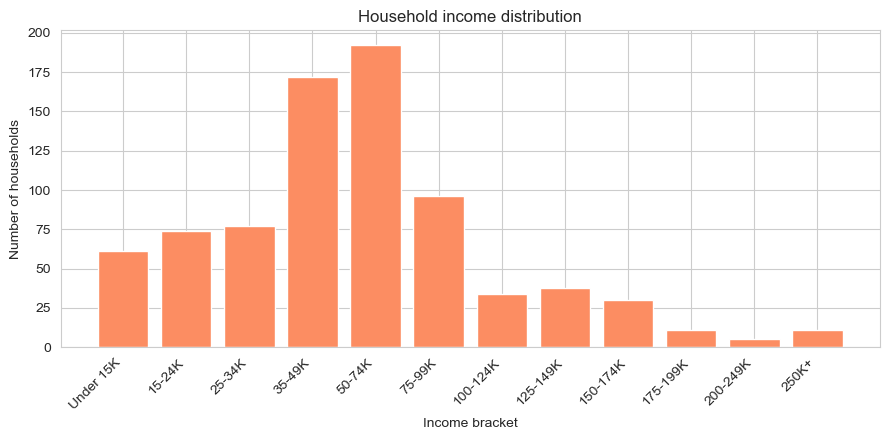

In [207]:
income_counts = hh_demographic["INCOME_DESC"].value_counts()  # đếm household theo từng mức thu nhập
income_order = sorted(income_counts.index, key=income_floor)  # sắp theo mốc thu nhập thấp -> cao

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(income_order, income_counts.reindex(income_order).values, color=COLORS[1])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Household income distribution")
ax.set_xlabel("Income bracket")
ax.set_ylabel("Number of households")
show_chart(fig)

**Sản phẩm bán gì?** Catalog theo department (số SKU) - đối chiếu với chart doanh thu theo department ngay bên dưới: nhiều SKU không có nghĩa là nhiều doanh thu.

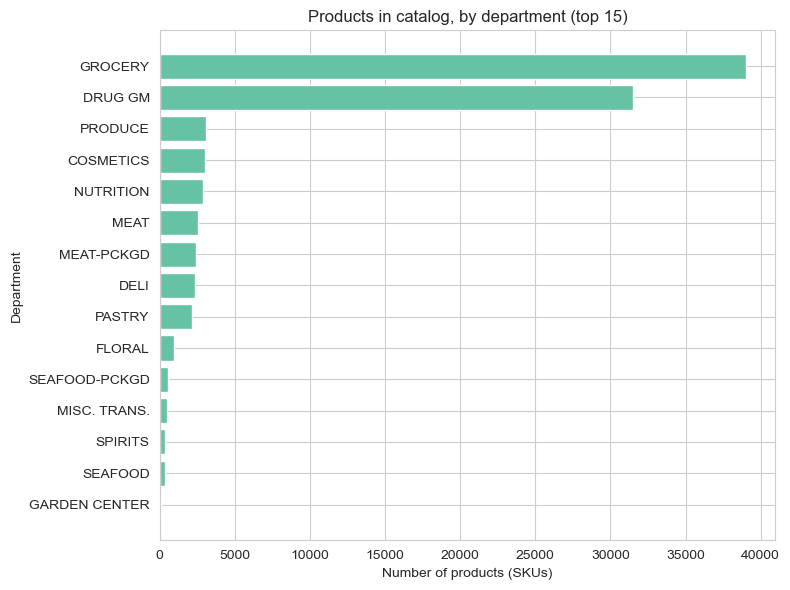

In [208]:
dept_counts = product["DEPARTMENT"].value_counts().head(15)  # đếm sản phẩm theo department, top 15

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(dept_counts.index[::-1], dept_counts.values[::-1], color=COLORS[0])
ax.set_title("Products in catalog, by department (top 15)")
ax.set_xlabel("Number of products (SKUs)")
ax.set_ylabel("Department")
show_chart(fig)

**Doanh thu đến từ đâu?** Department nào là nguồn doanh thu chính - đối chiếu với chart catalog ở trên.

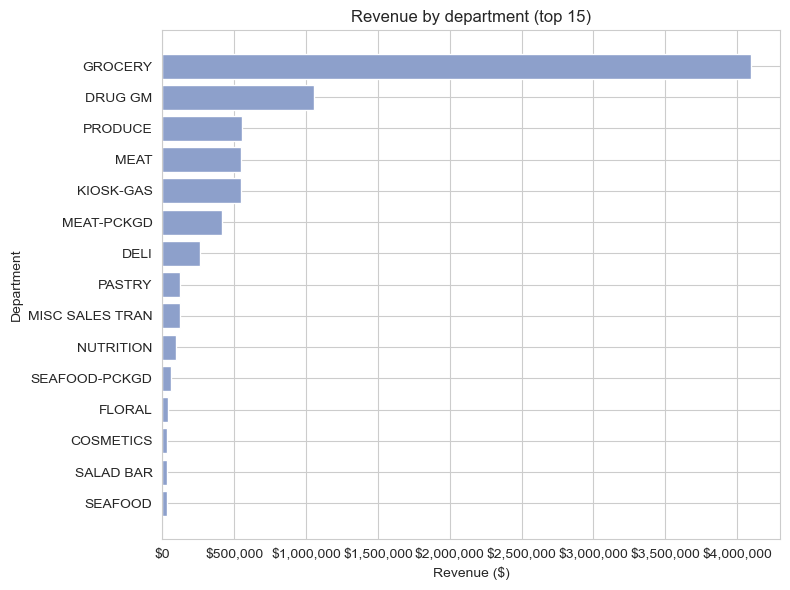

In [209]:
from matplotlib.ticker import FuncFormatter  # dùng để in số trên trục X có dấu $ và dấu phẩy ngăn cách

trans_with_dept = transaction_data.merge(product[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")  # nối thêm cột department
dept_rev = trans_with_dept.groupby("DEPARTMENT")["SALES_VALUE"].sum().sort_values(ascending=False).head(15)  # tổng doanh thu mỗi department

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(dept_rev.index[::-1], dept_rev.values[::-1], color=COLORS[2])
ax.set_title("Revenue by department (top 15)")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Department")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))  # 1750000 -> "$1,750,000" cho dễ đọc
show_chart(fig)

**Khuyến mãi có thật sự tăng doanh thu không (ở cấp sản phẩm)?** So sánh doanh thu trung bình khi sản phẩm được display/mailer vs. không - kết quả song song với kết luận chính của BQ1 (ở cấp household, Bước 3), nhưng nhìn từ góc sản phẩm.

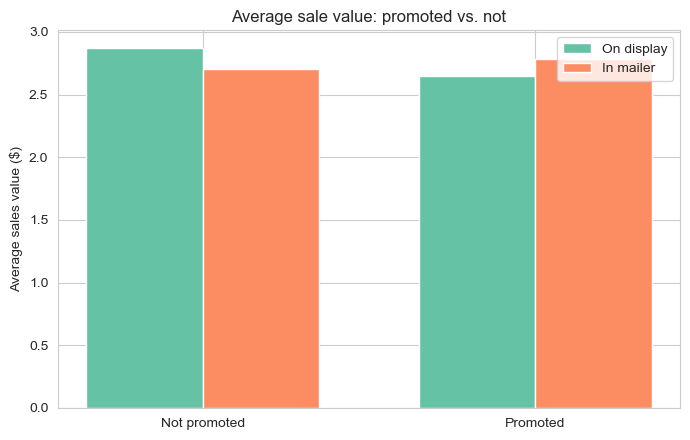

All EDA charts rendered above (no files written - display only)


In [210]:
causal = causal_data.copy()
causal["on_display"] = causal["display"].astype(str) != "0"  # "0" = không display, khác 0 = có display
causal["in_mailer"] = causal["mailer"].astype(str) != "0"  # tương tự cho mailer

causal_trans = transaction_data.merge(causal, on=["PRODUCT_ID", "STORE_ID", "WEEK_NO"], how="inner")  # nối transaction với thông tin khuyến mãi
display_avg = causal_trans.groupby("on_display")["SALES_VALUE"].mean()  # doanh thu TB: có display vs không
mailer_avg = causal_trans.groupby("in_mailer")["SALES_VALUE"].mean()  # doanh thu TB: có mailer vs không

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
width = 0.35
ax.bar(x - width / 2, [display_avg[False], display_avg[True]], width, label="On display", color=COLORS[0])
ax.bar(x + width / 2, [mailer_avg[False], mailer_avg[True]], width, label="In mailer", color=COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(["Not promoted", "Promoted"])
ax.set_title("Average sale value: promoted vs. not")
ax.set_ylabel("Average sales value ($)")
ax.legend()
show_chart(fig)

print("All EDA charts rendered above (no files written - display only)")

**BQ1 - Bước 2: Campaign nào target ai?** Ghép household bị target với dữ liệu demographic của họ. Lưu ý: chỉ 48% household bị target có đầy đủ dữ liệu demographic - số liệu in ra bên dưới, các chart sau chỉ dùng phần có dữ liệu này.

In [211]:
hh_type = campaign_table[["household_key", "DESCRIPTION"]].drop_duplicates()  # mỗi household - loại campaign, không lặp
targeting_demographics = hh_type.merge(hh_demographic, on="household_key", how="inner")  # chỉ giữ household có dữ liệu demographic

targeted_hh_count = hh_type["household_key"].nunique()
surveyed_hh_count = targeting_demographics["household_key"].nunique()
print(f"{surveyed_hh_count} of {targeted_hh_count} targeted households have demographic data "
      f"({surveyed_hh_count / targeted_hh_count:.0%}) - charts below use only that subset")

targeting_demographics.to_csv(os.path.join(OUT_DIR, "bq1_targeting_demographics.csv"), index=False)
demo_types = sorted(targeting_demographics["DESCRIPTION"].unique())

def pct_chart(dim_col, order, title, figsize=(9, 5)):
    # % of each campaign type's households in each bracket (percentages, not raw
    # counts, since campaign types reach very different numbers of households)
    pct = pd.crosstab(targeting_demographics[dim_col], targeting_demographics["DESCRIPTION"], normalize="columns") * 100
    pct = pct.reindex(order) if order else pct
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(pct))
    width = 0.8 / len(demo_types)
    for i, t in enumerate(demo_types):
        ax.bar(x + i * width - 0.4 + width / 2, pct[t], width, label=t, color=COLORS[i])
    ax.set_xticks(x)
    ax.set_xticklabels(pct.index, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel("% of that campaign type's households")
    ax.legend(title="Campaign type")
    show_chart(fig)

760 of 1584 targeted households have demographic data (48%) - charts below use only that subset


**So sánh độ tuổi giữa các loại campaign** - loại campaign nào nghiêng về nhóm tuổi nào?

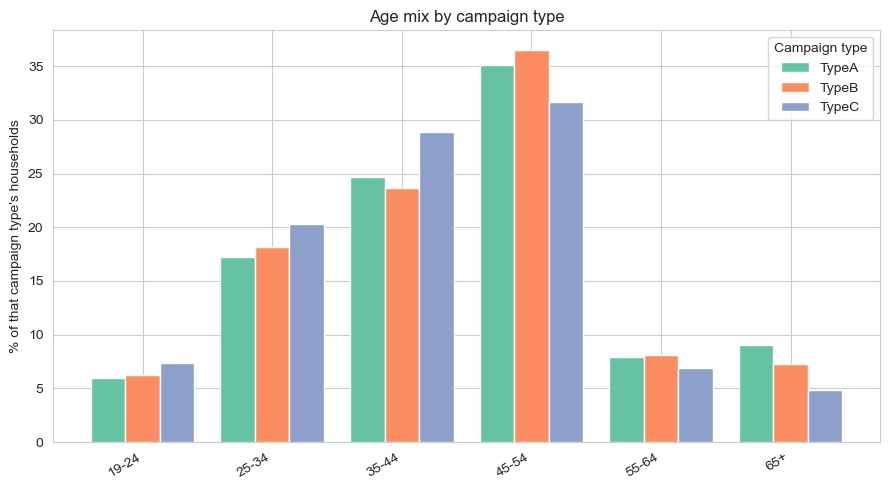

In [212]:
pct_chart("AGE_DESC", age_order, "Age mix by campaign type")

**So sánh thu nhập giữa các loại campaign** - câu trả lời trực tiếp cho phần đầu của BQ1 (ai bị target).

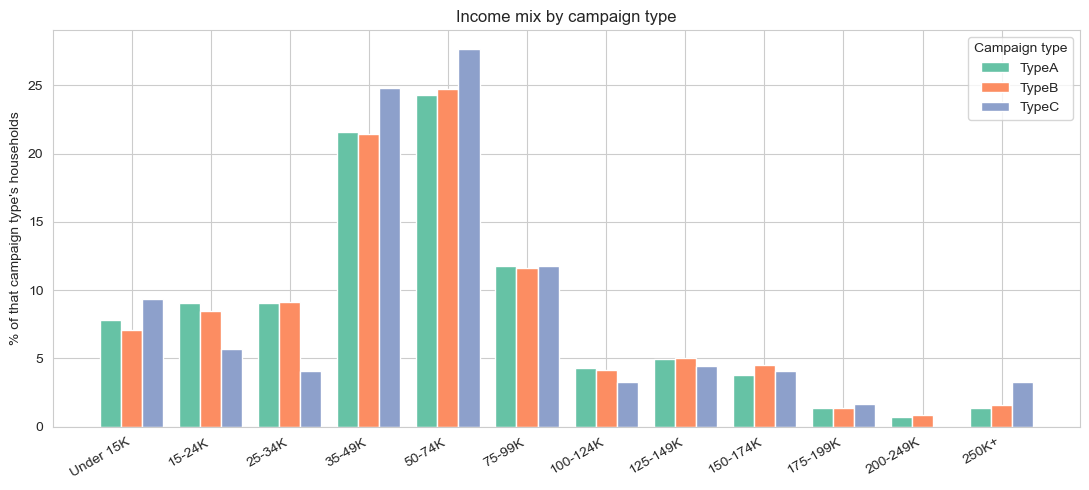

In [213]:
income_order = sorted(targeting_demographics["INCOME_DESC"].unique(), key=income_floor)
pct_chart("INCOME_DESC", income_order, "Income mix by campaign type", figsize=(11, 5))

**BQ1 - Bước 3: Chuẩn bị đo lường tác động chi tiêu.** Đây là bước lõi trả lời BQ1: chi tiêu có tăng lên khi household đang trong 1 campaign hay không. Hàm phụ này đếm số ngày household thực sự nằm trong ít nhất 1 campaign, không đếm trùng ngày khi 2 campaign chồng lịch (overlap).

In [214]:
def days_covered(starts, ends):
    days = set()  # dùng set để không đếm trùng ngày bị overlap
    for start, end in zip(starts, ends):
        days.update(range(start, end + 1))
    return len(days)

**Xác định khoảng ngày mỗi household bị target.** Với mỗi household, gom lại tất cả campaign window (ngày bắt đầu - kết thúc) mà họ bị target.

In [215]:
trans = transaction_data[["household_key", "DAY", "SALES_VALUE"]]

windows = campaign_table.merge(campaign_data, on="CAMPAIGN", how="left")[["household_key", "START_DAY", "END_DAY"]]  # ngày bắt đầu/kết thúc campaign cho từng household
targeted_hh = set(windows["household_key"].unique())

campaign_days = windows.groupby("household_key").apply(  # tổng số ngày mỗi household nằm trong campaign (không trùng)
    lambda g: days_covered(g["START_DAY"], g["END_DAY"])
)
study_span = trans["DAY"].max() - trans["DAY"].min() + 1  # tổng số ngày của toàn bộ dữ liệu
print(f"{len(targeted_hh)} targeted households, study span {study_span} days")

1584 targeted households, study span 711 days


/var/folders/qp/0rf5j_cd511f7kqzl7318x9m0000gn/T/ipykernel_15289/1285712608.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  campaign_days = windows.groupby("household_key").apply(  # tổng số ngày mỗi household nằm trong campaign (không trùng)


**Đánh dấu từng giao dịch: trong hay ngoài campaign.** Với hơn 2 triệu dòng giao dịch, dùng numpy so sánh mảng (vectorized) thay vì lặp `.apply()` từng dòng.

In [216]:
windows_by_hh = {hh: g[["START_DAY", "END_DAY"]].values for hh, g in windows.groupby("household_key")}  # gom window theo household để tra nhanh

flagged = []
for hh, group in trans[trans["household_key"].isin(targeted_hh)].groupby("household_key"):
    group = group.copy()
    starts, ends = windows_by_hh[hh][:, 0], windows_by_hh[hh][:, 1]
    days = group["DAY"].to_numpy()[:, None]
    group["in_campaign"] = ((days >= starts[None, :]) & (days <= ends[None, :])).any(axis=1)  # ngày giao dịch có nằm trong bất kỳ window nào không
    flagged.append(group)
targeted_trans = pd.concat(flagged, ignore_index=True)

other_trans = trans[~trans["household_key"].isin(targeted_hh)].copy()
other_trans["in_campaign"] = False  # household không bị target -> luôn tính là ngoài campaign
combined = pd.concat([targeted_trans, other_trans], ignore_index=True)

**Tính chi tiêu trung bình mỗi ngày: trong vs. ngoài campaign, rồi chia segment.** Segment chia theo chi tiêu NGOÀI campaign (không phải trong campaign) để tránh circular logic.

In [217]:
spend_in = combined[combined["in_campaign"]].groupby("household_key")["SALES_VALUE"].sum()  # tổng chi tiêu trong lúc có campaign
spend_out = combined[~combined["in_campaign"]].groupby("household_key")["SALES_VALUE"].sum()  # tổng chi tiêu ngoài campaign

summary = pd.DataFrame(index=sorted(combined["household_key"].unique()))
summary["days_in_campaign"] = campaign_days.reindex(summary.index).fillna(0)
summary["days_outside_campaign"] = study_span - summary["days_in_campaign"]
summary["spend_in_campaign"] = spend_in.reindex(summary.index).fillna(0)
summary["spend_outside_campaign"] = spend_out.reindex(summary.index).fillna(0)
summary["avg_daily_spend_in_campaign"] = summary["spend_in_campaign"] / summary["days_in_campaign"]  # quy về chi tiêu/ngày để so sánh công bằng
summary["avg_daily_spend_outside_campaign"] = summary["spend_outside_campaign"] / summary["days_outside_campaign"]

# chỉ giữ household thực sự có ít nhất 1 ngày trong campaign
targeted_summary = summary[summary["days_in_campaign"] > 0].copy()
# % chênh lệch chi tiêu: trong campaign so với ngoài campaign
targeted_summary["lift_pct"] = (
    (targeted_summary["avg_daily_spend_in_campaign"] - targeted_summary["avg_daily_spend_outside_campaign"])
    / targeted_summary["avg_daily_spend_outside_campaign"] * 100
)

# segment by OUTSIDE-campaign spend, so the segment isn't defined by the thing being measured
targeted_summary["value_segment"] = pd.qcut(
    targeted_summary["avg_daily_spend_outside_campaign"], q=4,
    labels=["Low value", "Med-low value", "Med-high value", "High value"],
)

targeted_summary.to_csv(os.path.join(OUT_DIR, "bq1_campaign_spending_impact.csv"), index_label="household_key")
print(f"{len(targeted_summary)} targeted households with a valid in/out comparison")

1584 targeted households with a valid in/out comparison


**Kết luận BQ1: % lift chi tiêu theo từng segment.** Chart trả lời chính cho toàn bộ BQ1 - segment nào tăng chi tiêu nhiều nhất khi có campaign. Đường kẻ ngang tại 0 là mốc "không đổi" để so sánh.

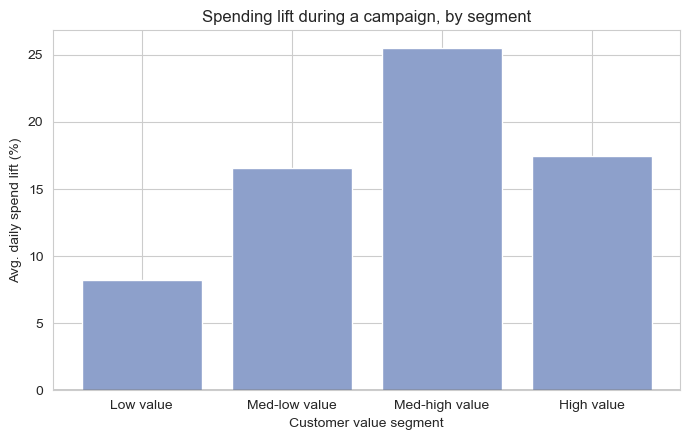

All BQ1 CSV outputs saved to: outputs (charts rendered above only)


In [218]:
seg_order = ["Low value", "Med-low value", "Med-high value", "High value"]

lift_by_seg = targeted_summary.groupby("value_segment", observed=True)["lift_pct"].mean().reindex(seg_order)  # % lift trung bình mỗi segment

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(lift_by_seg.index, lift_by_seg.values, color=COLORS[2])
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Spending lift during a campaign, by segment")
ax.set_xlabel("Customer value segment")
ax.set_ylabel("Avg. daily spend lift (%)")
show_chart(fig)

print(f"All BQ1 CSV outputs saved to: {OUT_DIR} (charts rendered above only)")

**Q1 - Output 1: bảng tổng hợp campaign** - đủ cả 30 campaign, kể cả campaign có 0 coupon/household ("Do not drop anything, no duplicates") - mọi phép tính đều reindex + fillna(0) thay vì inner join. Đứng độc lập, không cần chạy BQ1 trước.

In [219]:
# "Do not drop anything (no duplicates)": mỗi campaign trong 30 campaign phải xuất hiện
# trong bảng dưới đây, kể cả campaign có 0 coupon hoặc 0 household - nên mọi lookup
# đều được reindex về full danh sách campaign rồi fillna(0) thay vì dùng inner join
# (inner join có thể làm rớt mất campaign không khớp).
all_campaigns = campaign_data.drop_duplicates(subset="CAMPAIGN").set_index("CAMPAIGN")
campaign_summary = all_campaigns[["DESCRIPTION", "START_DAY", "END_DAY"]].rename(
    columns={"DESCRIPTION": "CAMPAIGN_TYPE"}
)
campaign_summary["DURATION_DAYS"] = all_campaigns["END_DAY"] - all_campaigns["START_DAY"] + 1

households_per_campaign = campaign_table.groupby("CAMPAIGN")["household_key"].nunique()  # số household khác nhau mỗi campaign
coupons_per_campaign = coupon_table.groupby("CAMPAIGN")["COUPON_UPC"].nunique()  # số coupon khác nhau mỗi campaign
products_per_campaign = coupon_table.groupby("CAMPAIGN")["PRODUCT_ID"].nunique()  # số sản phẩm khác nhau mỗi campaign

# nối coupon_table với product để lấy department, rồi đếm số category (department) khác nhau mỗi
# campaign - tự làm thay vì mượn campaign_product_map (BQ1 Step 1), để Q1 không phụ thuộc BQ1 nữa
coupon_with_dept = coupon_table.merge(product[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")
categories_per_campaign = coupon_with_dept.groupby("CAMPAIGN")["DEPARTMENT"].nunique()  # số department khác nhau mỗi campaign

campaign_summary["N_HOUSEHOLDS_TARGETED"] = households_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)
campaign_summary["N_COUPONS"] = coupons_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)
campaign_summary["N_PRODUCTS"] = products_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)
campaign_summary["N_CATEGORIES"] = categories_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)

# doanh thu "associated with campaign period" = tổng sales trong khoảng ngày của campaign,
# tính trên toàn bộ household (các campaign có thể overlap về thời gian, nên 1 giao dịch
# có thể hợp lệ được tính vào nhiều hơn 1 campaign)
revenue_per_campaign = {
    camp: transaction_data.loc[
        (transaction_data["DAY"] >= row["START_DAY"]) & (transaction_data["DAY"] <= row["END_DAY"]), "SALES_VALUE"
    ].sum()
    for camp, row in campaign_summary.iterrows()
}
campaign_summary["TOTAL_REVENUE"] = pd.Series(revenue_per_campaign)

campaign_summary.to_csv(os.path.join(OUT_DIR, "q1_campaign_summary.csv"))
print(f"{len(campaign_summary)} campaigns in the table (should be 30 - none dropped)")
campaign_summary

30 campaigns in the table (should be 30 - none dropped)


,CAMPAIGN_TYPE,START_DAY,END_DAY,DURATION_DAYS,N_HOUSEHOLDS_TARGETED,N_COUPONS,N_PRODUCTS,N_CATEGORIES,TOTAL_REVENUE
CAMPAIGN,,,,,,,,,
24,TypeB,659,719,61,100,2,1887,4,692074.73
15,TypeC,547,708,162,17,2,55,1,2092165.30
25,TypeB,659,691,33,187,17,826,5,442635.75
20,TypeC,615,685,71,244,24,609,2,938703.05
23,TypeB,646,684,39,183,18,767,3,518152.94
21,TypeB,624,656,33,65,16,242,6,445814.41
22,TypeB,624,656,33,276,21,1917,4,445814.41
18,TypeA,587,642,56,1133,209,35513,28,751569.98
19,TypeB,603,635,33,130,11,375,1,430047.30


**Q1 - Output 2: phân loại Small/Medium/Large** - dùng số household được target (reach) làm tiêu chí, chia 3 nhóm bằng nhau (qcut), chọn 1 campaign gần median nhất mỗi nhóm làm đại diện, cộng thêm ví dụ doanh thu cao nhất/thấp nhất.

In [220]:
# Chosen metric: number of households targeted (= campaign reach). It's a direct,
# easy-to-defend measure of "size" and it already varies a lot between campaigns
# (see the campaign_table_01 chart above) - split into 3 equal-sized groups by reach.
campaign_summary["SIZE"] = pd.qcut(
    campaign_summary["N_HOUSEHOLDS_TARGETED"], q=3, labels=["Small", "Medium", "Large"]
)

def pick_typical(bucket):
    # the campaign closest to the bucket's own median reach - more representative
    # than an arbitrary first row or a random pick
    median_reach = bucket["N_HOUSEHOLDS_TARGETED"].median()
    return (bucket["N_HOUSEHOLDS_TARGETED"] - median_reach).abs().idxmin()

examples = {
    size: pick_typical(campaign_summary[campaign_summary["SIZE"] == size])
    for size in ["Small", "Medium", "Large"]
}
examples["Highest-revenue"] = campaign_summary["TOTAL_REVENUE"].idxmax()
examples["Lowest-revenue"] = campaign_summary["TOTAL_REVENUE"].idxmin()

for label, camp in examples.items():
    print(f"{label} example: campaign {camp}")

campaign_summary.loc[list(examples.values())]

Small example: campaign 15
Medium example: campaign 12
Large example: campaign 22
Highest-revenue example: campaign 15
Lowest-revenue example: campaign 4


,CAMPAIGN_TYPE,START_DAY,END_DAY,DURATION_DAYS,N_HOUSEHOLDS_TARGETED,N_COUPONS,N_PRODUCTS,N_CATEGORIES,TOTAL_REVENUE,SIZE
CAMPAIGN,,,,,,,,,,
15,TypeC,547,708,162,17,2,55,1,2092165.30,Small
12,TypeB,477,509,33,170,15,620,3,415911.01,Medium
22,TypeB,624,656,33,276,21,1917,4,445814.41,Large
15,TypeC,547,708,162,17,2,55,1,2092165.30,Small
4,TypeB,372,404,33,81,12,200,2,406075.38,Small
